In [156]:
import numpy as np
import pandas as pd


In [157]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [158]:
df = pd.read_csv('/content/drive/MyDrive/spam_dataset/spam.csv', encoding='latin-1')

In [159]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [160]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [161]:
df.shape

(5572, 5)

In [162]:
# 1. data cleaning 2. eda 3. text preprocessing 4. model 5. evaluation 6. improvement

data cleaning


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [164]:
# drop last 3 coloumns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)


In [165]:
df.sample()

,v1,v2
5229,ham,It means u could not keep ur words.


In [166]:
# renaming columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample()
#

,target,text
1968,ham,2 laptop... I noe infra but too slow lar... I ...


In [167]:
# label encoder for spam and ham
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [168]:
df['target'] = encoder.fit_transform(df['target'])

In [169]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [170]:
# missing values
df.isnull() .sum()

,0
target,0
text,0


In [171]:
# check for duplicate values
df.duplicated() .sum()

np.int64(403)

In [172]:
#remove duplicates
df = df.drop_duplicates(keep='first')

In [173]:
df.duplicated() .sum()

np.int64(0)

In [174]:
df.shape

(5169, 2)

EDA

In [175]:
df['target'].value_counts()

,count
target,
0,4516
1,653


In [176]:
import matplotlib.pyplot as plt

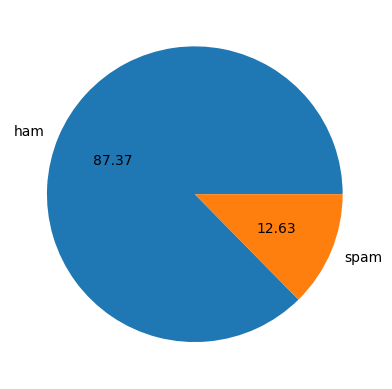

In [177]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [178]:
# data is imbalanced

In [179]:
# new columns for more analysis -> no. of chars, para, lines

In [180]:
!pip install nltk

In [181]:
import nltk

In [182]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [183]:
df['chars'] = df['text'].apply(len)

In [184]:
nltk.download('punkt_tab')
# num of words
df['words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [185]:
df.sample(3)

,target,text,chars,words
4680,0,Are you staying in town ?,25,6
3480,0,Wherre's my boytoy ? :-(,24,8
2042,0,"Me not waking up until 4 in the afternoon, sup",46,11


In [186]:
# number of sentences
df['sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [187]:
df.describe()

,target,chars,words,sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [188]:
# seeing seperately for ham and spam
#ham
df[df['target'] == 0][['chars','words','sentences']].describe()

,chars,words,sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [189]:
#spam
df[df['target'] == 1][['chars','words','sentences']].describe()

,chars,words,sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [190]:
#plot histogram for both cats


In [191]:
import seaborn as sns

<Axes: xlabel='chars', ylabel='Count'>

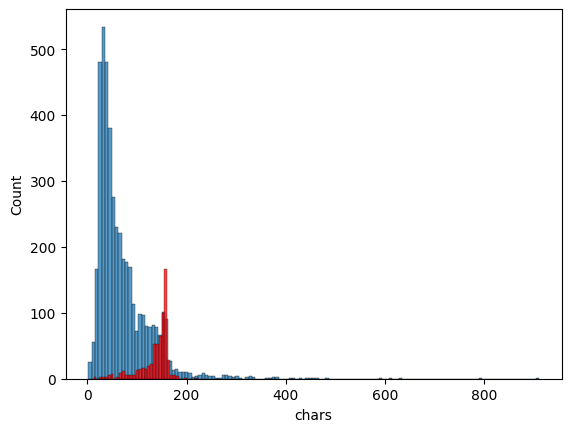

In [192]:
sns.histplot(df[df['target'] == 0]['chars'])
sns.histplot(df[df['target'] == 1]['chars'], color='red')


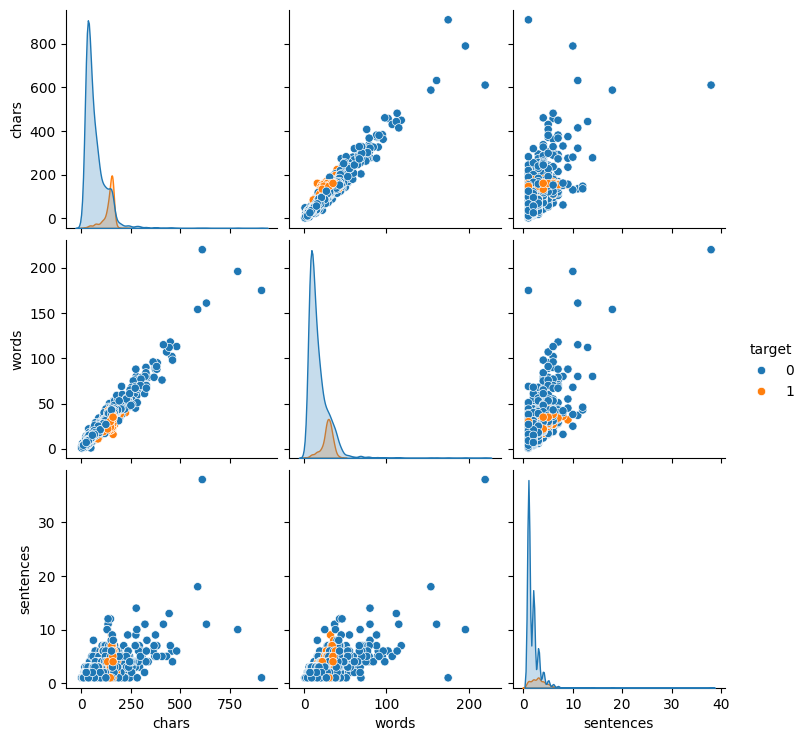

In [193]:
sns.pairplot(df, hue = 'target')

<Axes: >

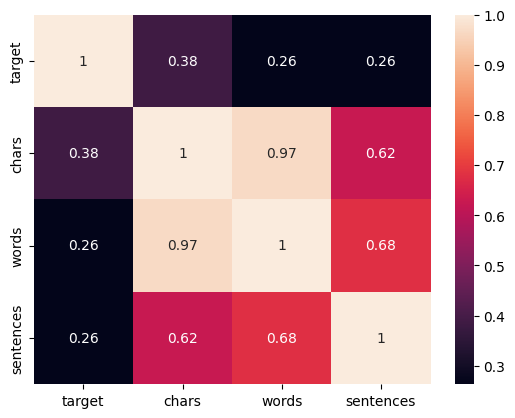

In [194]:
sns.heatmap(df[['target', 'chars', 'words', 'sentences']].corr(), annot=True)

# Data Preprocessing
- lower case
- tokenization
- removing special chars
- removing stop words and punctuation
- stemming

In [195]:
import string
from nltk.corpus import stopwords

def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    ps.stem(i)
    y.append(ps.stem(i))

  return " ".join(y)

In [196]:
# nltk.download('stopwords')
# stopwords.words('english')

In [197]:
transform_text('Hi my name is Rohan and im studying machine learning')

'hi name rohan im studi machin learn'

In [198]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [199]:
ps.stem('loving')

'love'

In [200]:
df['transformed_text'] = df['text'].apply(transform_text)

In [201]:
from wordcloud import WordCloud

In [202]:
wc = WordCloud(width = 500, height=500, min_font_size=10, background_color='white')

In [203]:
# imports needed for transform_text_fixed (might be redundant if already imported globally, but safe for self-contained cell)
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer() # Initialize PorterStemmer

# Redefine a corrected version of the text transformation function
def transform_text_fixed(text):
  # Lower case
  text = text.lower()
  # Tokenization
  text = nltk.word_tokenize(text)

  y = []
  # Removing non-alphanumeric characters
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  # Removing stop words and punctuation
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  # Stemming
  for i in text:
    y.append(ps.stem(i))

  # Return space-separated words for WordCloud
  return " ".join(y)

# Apply the fixed transformation and generate the word cloud
spam_wc = wc.generate(df[df['target'] == 1]['text'].apply(transform_text_fixed).str.cat(sep=" "))

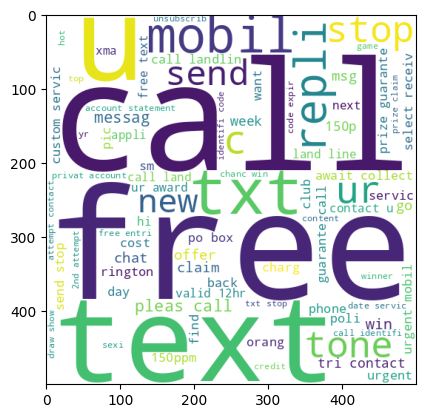

In [204]:
plt.imshow(spam_wc)

In [205]:
ham_wc = wc.generate(df[df['target'] == 0]['text'].apply(transform_text_fixed).str.cat(sep=" "))

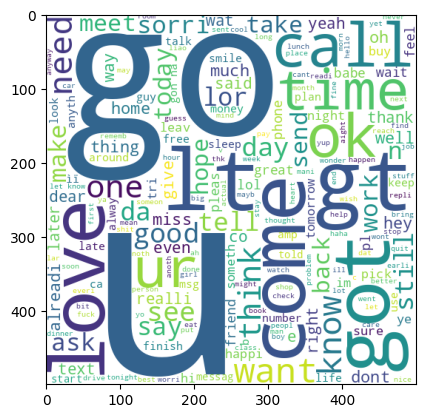

In [206]:
plt.imshow(ham_wc)

In [207]:
df.head()

,target,text,chars,words,sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [208]:
spam_corpus = []

# Re-apply the text transformation logic to the original 'text' column
# This ensures we get individual, space-separated stemmed words
for original_text in df[df['target'] == 1]['text'].tolist():
  # Lower case
  text = original_text.lower()
  # Tokenization
  text = nltk.word_tokenize(text)

  temp_words = []
  # Removing non-alphanumeric characters
  for i in text:
    if i.isalnum():
      temp_words.append(i)

  # Removing stop words and punctuation
  processed_words = []
  for i in temp_words:
    if i not in stopwords.words('english') and i not in string.punctuation:
      processed_words.append(i)

  # Stemming
  stemmed_words = []
  for i in processed_words:
    stemmed_words.append(ps.stem(i))

  spam_corpus.extend(stemmed_words)

In [209]:
len(spam_corpus)

9939

In [210]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

# MODEL BUILDING
- naive baye's algorithm -> for text based

In [211]:
# text vectorisation using bag of words

In [212]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [213]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [214]:
X.shape

(5169, 6708)

In [215]:
y = df['target'].values

In [216]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [217]:
from sklearn.model_selection import train_test_split

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [219]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [220]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [221]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [222]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [223]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283
